# Predicting Listing Prices for Airbnb NYC, Exploring of Different Predictive Models

## Part II: Data Preparation for ML Models
  - 2.1. Checking for Duplicate Rows and Handling Missing Values
  - 2.2. Handling Outliers
  - 2.3. Feature Engineering
    - 2.3.1. NLP for the'name' Column - Word Embedding
    - 2.3.2. Dimensionality Reduction: Principal Component Analysis (PCA) for the New
- Columns
    - 2.3.3. One-Hot-Encoding (OHE) for categorical variables

#### Importing Libraries

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
matplotlib.style.use('seaborn-v0_8')
from mpl_toolkits import mplot3d
import matplotlib.cm as cm

from nltk.corpus import stopwords
import nltk
#downloading stopwords
nltk.download('stopwords')

#for text pre-processing 
import string
import re
import gensim
import os

from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
#showing all outputs in a cell 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

[nltk_data] Downloading package stopwords to /Users/varia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv('Airbnb_ml_project/data/processed/airbnb_part1_analysis.csv')
df.head()

,id,name,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,74860,"Sunlit and Cozy Williamsburg/Greenpoint, Brooklyn",Brooklyn,40.72488,-73.95018,Private room,55,2,1,2011-03-28,0.01,1,0
1,40039,Luxurious Condo in DUBMO with View,Brooklyn,40.70207,-73.98571,Private room,250,3,14,2011-04-25,0.13,1,189
2,81739,Loft w/ Terrace @ Box House Hotel,Brooklyn,40.73842,-73.95312,Private room,249,3,2,2011-05-12,0.02,28,60
3,28396,Modern Apt with Spectacular Views,Brooklyn,40.71923,-73.96468,Private room,90,1,9,2011-09-18,0.08,1,245
4,32363,Fully Furnished Basement Apartment,Queens,40.74028,-73.83168,Private room,140,2,1,2011-09-19,0.01,1,1


# 2. Data Preparation for ML Models

#### 2.1. Checking for Duplicate Rows and Handling Missing Values

In [3]:
print(f'The total Number of duplicate rows in the dataset (across all columns): {df.duplicated().sum()}')
#OR:
#df[df.duplicated()].shape

The total Number of duplicate rows in the dataset (across all columns): 0


In [4]:
df.isna().sum() 

id                                    0
name                                 16
neighbourhood_group                   0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

last_review and reviews_per_month  had the same number of missing values, with same cases missing,and corresponding to 0 reviews.

In [5]:
df[(df.last_review.isna())&(df.reviews_per_month.isna())].shape

(10052, 13)

In [6]:
#all NaN values in 'last_review' and 'reviews_per_month' corresponded to 0 'number_of_reviews'
df[(df.number_of_reviews == 0)&(df.last_review.isna())&(df.reviews_per_month.isna())].shape

(10052, 13)

In [7]:
#filling the NaN values for last review with 0, since they correspond to 0 reviews per month
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [8]:
# converting last review to datetime
df['last_review'] = pd.to_datetime(df['last_review'])
print(df['last_review'].dtype)

datetime64[us]


Filling missing last_review values, corresponding to listings with 0 reviews, with a date earlier than the earliest real review date in the dataset, so "no reviews yet" is represented numerically rather than as NaN. This would allow missing values in the 'last_review' column corresponding to 0 reviews to be represented by a date earlier than the earliest date present in the dataset.

In [9]:
earliest_date = df['last_review'].min()
# Filling the Missing Values in the 'last_review' column with a date earlier than the earliest date present in the dataset.
df['last_review'] = df['last_review'].fillna(pd.Timestamp('1900-01-01'))
#replacing these values with np.nan for them to be recognised as missing values again - so that we can replace themw ith the mode of the dataset.
df.loc[df['last_review'] == pd.Timestamp('1900-01-01'), 'last_review'] = np.nan

For the categorical feature(last_review), filling missing values with the mode would result in most exact approximation(Gigerenzer,2004).

In [10]:
#Now the NaN values in 'last_review' can be filled in with the column's mode 
#selecting mode()[0], since there could be several modes in the column 
#thus, signalling that the 1st mode should be selected
df['last_review'] = df['last_review'].fillna(df['last_review'].mode()[0])

In [11]:
# Converting non-null 'last_review' values to integer format
df['last_review'] = df['last_review'].astype('int64') // 10**9
df.head()

,id,name,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,74860,"Sunlit and Cozy Williamsburg/Greenpoint, Brooklyn",Brooklyn,40.72488,-73.95018,Private room,55,2,1,1301270,0.01,1,0
1,40039,Luxurious Condo in DUBMO with View,Brooklyn,40.70207,-73.98571,Private room,250,3,14,1303689,0.13,1,189
2,81739,Loft w/ Terrace @ Box House Hotel,Brooklyn,40.73842,-73.95312,Private room,249,3,2,1305158,0.02,28,60
3,28396,Modern Apt with Spectacular Views,Brooklyn,40.71923,-73.96468,Private room,90,1,9,1316304,0.08,1,245
4,32363,Fully Furnished Basement Apartment,Queens,40.74028,-73.83168,Private room,140,2,1,1316390,0.01,1,1


In [12]:
#Checking whether the transformation was successful
print(df['last_review'].dtype)

int64


In [13]:
#'name' column NaNs represent no descripption given
#hence, filling nans with 'no description'
df['name'] = df['name'].fillna('No Description')

#### 2.2. Handling Outliers

Winzorisation was applied for outliers for the highly-skewed data nature (Gigerenzer,2004).

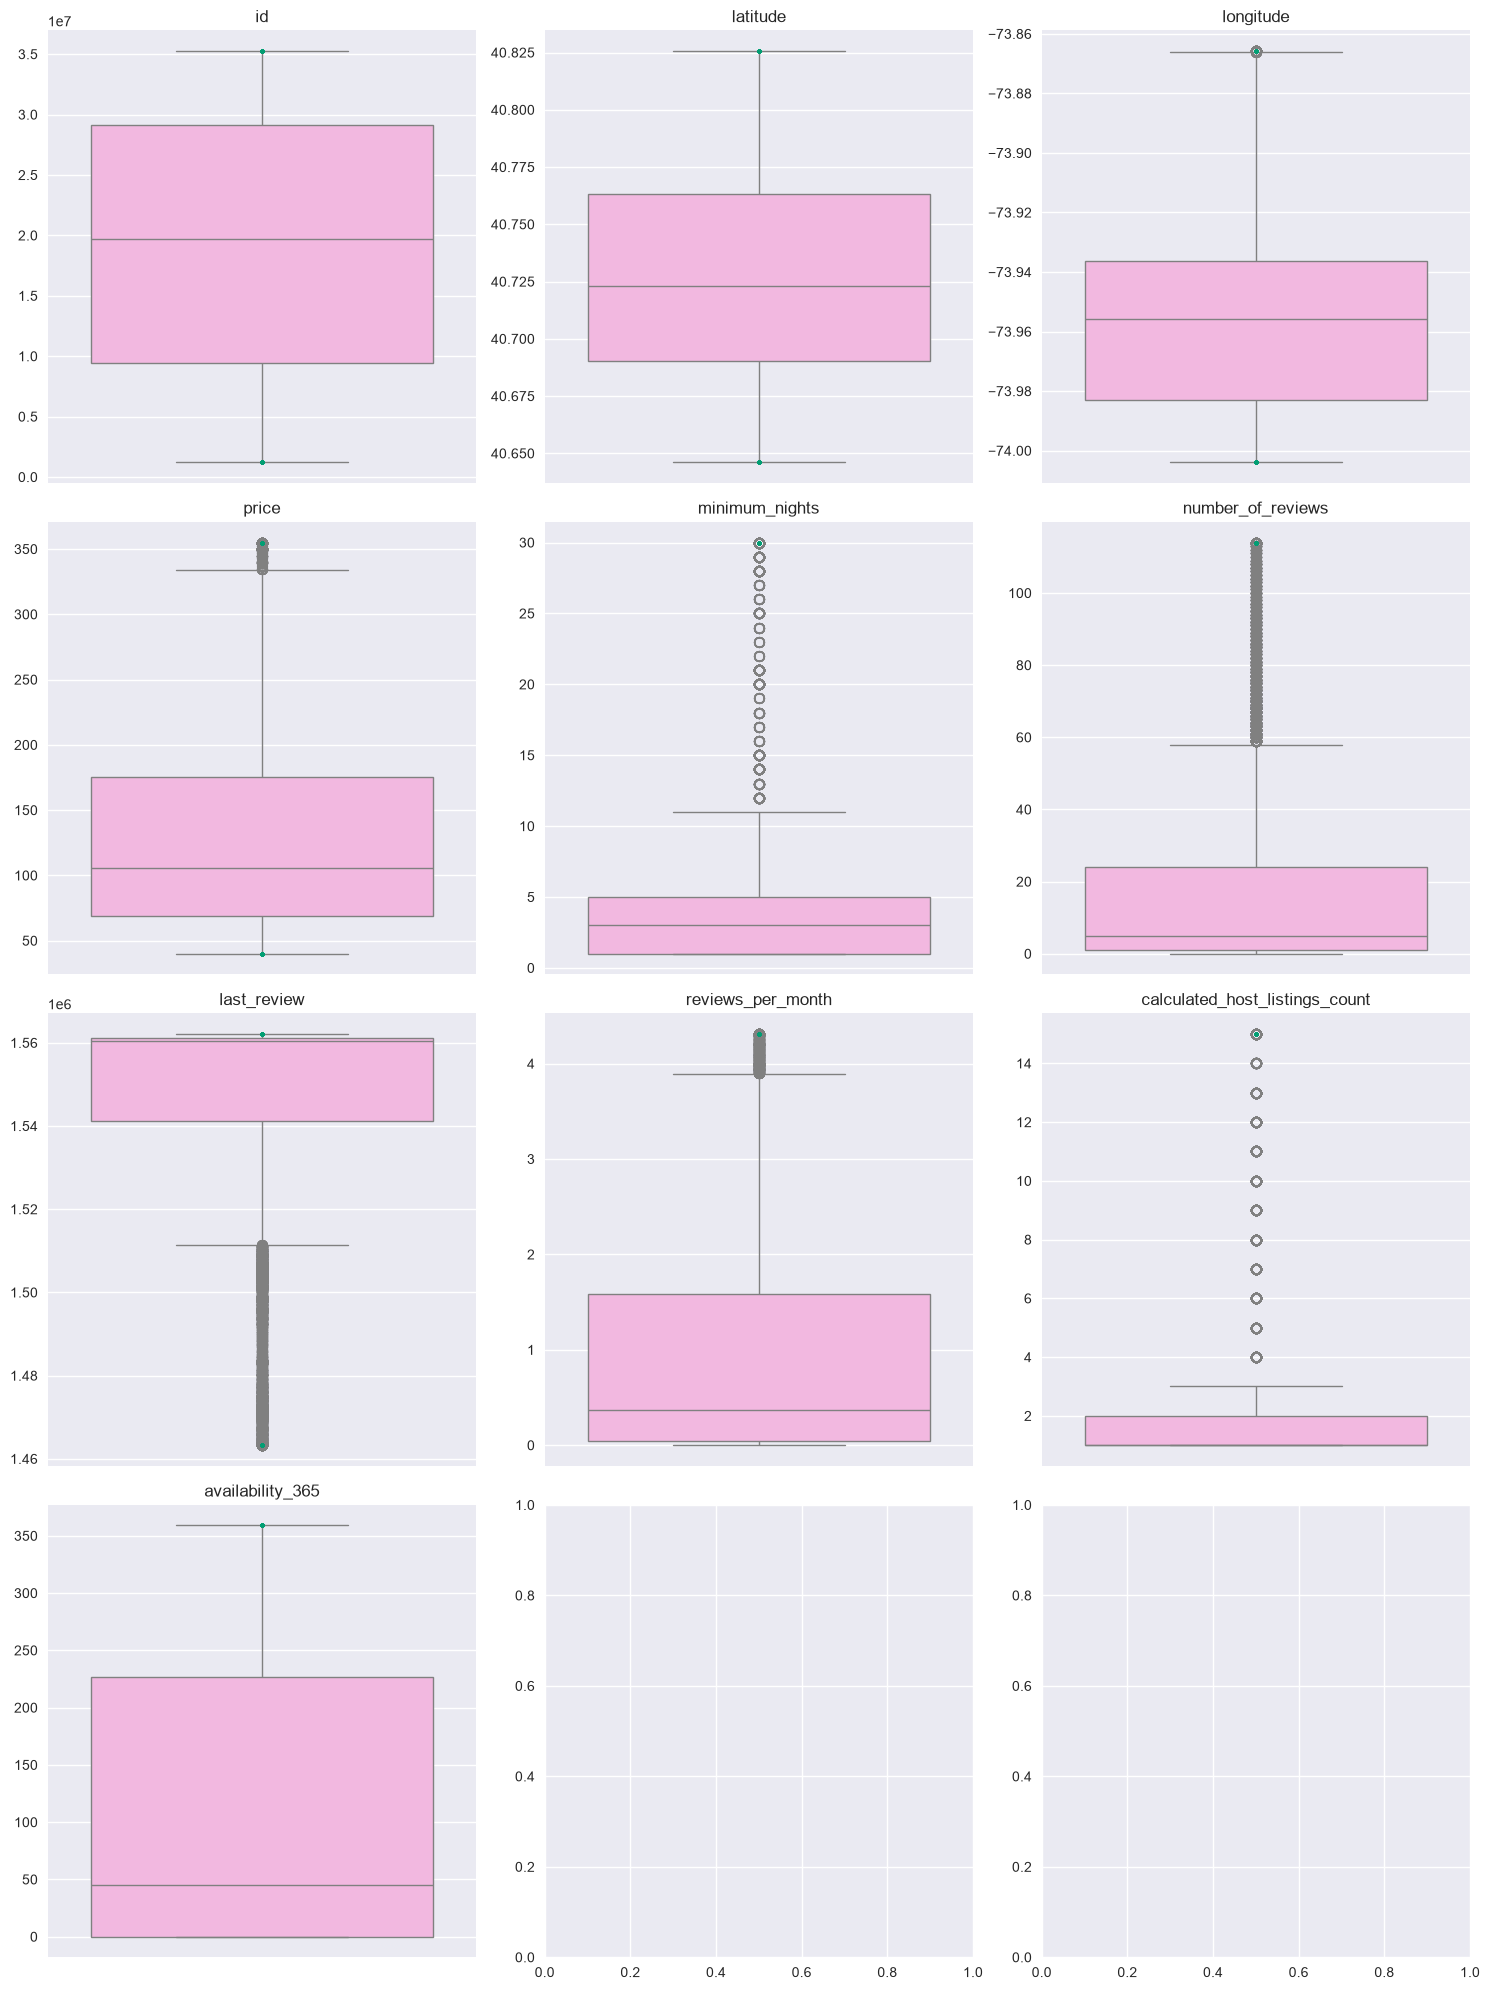

In [14]:
#checking for outliers
# Selecting only the numeric columns from the Df for plotting
numeric_df = df.select_dtypes(include='number')
# Calculating the 5th and 95th percentiles for each numeric column
p05 = numeric_df.quantile(0.05)
p95 = numeric_df.quantile(0.95)
# Calculating outliers based on the original (pre-Winsorized) data
outliers = (numeric_df < p05) | (numeric_df > p95)
# Winsorization: Replacing outliers with the 
#nearest non-outlier value 
for col in numeric_df.columns:
    q05 = p05[col]
    q95 = p95[col]
    numeric_df[col] = np.where(numeric_df[col] < q05, q05, 
                               np.where(numeric_df[col] > q95, 
                               q95, numeric_df[col]))
# Creating a grid of subplots
n_cols = 3
n_rows = (numeric_df.shape[1] - 1) // n_cols + 1
fig, axs = plt.subplots(nrows = n_rows, ncols = n_cols, 
                        figsize = (15, 5*n_rows))
# Looping through each numeric column and creating a boxplot
for i, col in enumerate(numeric_df.columns):
    ax = axs[i//n_cols, i%n_cols]
    sns.boxplot(data = numeric_df[col], ax = ax, 
                color = sns.color_palette('colorblind')[6], 
                orient = 'v')
    sns.stripplot(data = numeric_df[col][outliers[col]],
                  ax = ax, 
                  color = sns.color_palette('colorblind')[2], 
                  orient = 'v', jitter = 0, size = 3)
    ax.set_title(col)
    ax.set_ylabel('')
# Removing any unused subplots and adjust spacing
for ax in axs.flat[n_rows*n_cols:]:
    ax.remove()
plt.tight_layout()
# Showing the plot
plt.show();

##### Removing outliers in the original df

In [15]:
#selecting numeric columns in the original df
numeric_cols = df.select_dtypes(include = 'number').columns.tolist()
# Calculating the 5th and 95th percentiles 
#for each numeric column
p05 = df[numeric_cols].quantile(0.05)
p95 = df[numeric_cols].quantile(0.95)
# Replacing outliers in the original data
for col in numeric_cols:
    df[col] = np.where(df[col] < p05[col], p05[col], 
                       np.where(df[col] > p95[col],
                                p95[col], df[col]))
# Checking if any outliers remain in the data
outliers_df = ((df[numeric_cols] < p05) | (df[numeric_cols] > p95)).any().any()
if outliers_df:
    print('Outliers are still present in the merged df')
else:
    print('All outliers have been removed from merged df! Congrats!')

All outliers have been removed from merged df! Congrats!


## 2.3. Feature Engineering

### 2.3.1 NLP for the 'name' Column: Word Embedding

For almost every 'name' column instance being unique, One-Hot-Encoding (OHE) would be inappropriate. Word embedding was selected for text-preprocessing for capturing text relationships and allowing for further feature space dimensionality reduction, potentially increasing predictive models' accuracy (Cambria & White, 2014).

In [16]:
# Finding the number of unique instances in 'Column2'
num_unique_name = df['name'].nunique()
print(f'The number of unique instances in the \'name\' column is: {num_unique_name}')

The number of unique instances in the 'name' column is: 47906


In [17]:
max_length_name = df['name'].apply(lambda x: len(str(x))).max()
print(max_length_name)

179


As a first Word Embedding step, text Preprocessing was performed to clean and standardise test data toensure same words' variations are minimised, facilitating meaning extraction.

In [18]:
# Setting a random seed to ensure results' reproducibility
np.random.seed(28)
# Defining the function for text preprocessing
def preprocess_text(text):
    # Converting the text to lowercase
    text = text.lower()
    # Removing any punctuation present
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Removing any digits present
    text = re.sub(r'\d+', '', text)
    # Removing any extra whitespaces present
    text = re.sub(r'\s+', ' ', text)
    # Removing stop words with <3 letters
    stop_words = set(stopwords.words('english'))
    stop_words = [word for word in stop_words if len(word) > 3]
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text.strip()
# Applying the preprocessing function to the 'name' column
df['name'] = df['name'].apply(preprocess_text)

Next, a tokeniser, mapping words to indices was created, and text data tokenised. The Word2Vec Model (Gensim library) was then trained on tokenised text to obtain word embeddings (dense numerical words' representation) (Shi & Liu, 2014).

In [19]:
#(using Keras Tokenizer class)
# Creating a tokeniser and fitting it on the 'name' column
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['name'])
# Creating a dictionary to map words to indices
word2idx = tokenizer.word_index
# Creating a list of tokenised sentences
sentences = tokenizer.texts_to_sequences(df['name'])
# Training a Word2Vec model on sentences
model = gensim.models.Word2Vec(sentences, vector_size=100,
                               window=5, min_count=1, workers=4, seed=28)

Then, pre-trained GloVe embeddings were loaded to augment tembeddings obtained from the Word2Vec model. Glove provides fixed-length numerical representation for each vocabulary word. GloVe was selected due to it being pre-trained with vast text data and demonstrating decent performance across tasks (Shi& Liu,2014).

To use glove embeddings (Global Vectors for Word Representation), copy the following commands into the terminal:

1st command: wget http://nlp.stanford.edu/data/glove.6B.zip 
-> to download  a zip file containing 
pre-trained Glove embeddings (file glove.6B.zip)

2nd command: unzip glove.6B.zip -d glove/ -> unzipping the downloaded file and extracting embeddings into glove/ directory of the project

To strike an optimal balance between computational feasibility and capturing significant information from the input data, the embedding dimension of 100(widely adopted) was selected.

In [20]:
# Loading pre-trained GloVe embeddings
EMBEDDING_DIM = 100
embedding_index = {}
with open(os.path.join('glove', 'glove.6B.100d.txt'), encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype = 'float32')
        embedding_index[word] = coefs

Then, the embedding matrix for the vocabulary was created and will represent each word as a dense numerical vector. Iterating through each vocabulary word in Word2Vec and checking for a corresponding Glove embedding. This would allow to generate an embedding matric combining both Word2Vec trained on Airbnb Dataset's 'name' column and Glove Embeddings, improving predictive models' performance (Li & Yang, 2018).

In [21]:
# Creating an embedding matrix for our vocabulary
vocabulary_size = len(word2idx) + 1
embedding_matrix = np.random.uniform(low=-0.05, 
                      high=0.05, size=(vocabulary_size, 179))
# Updating the embedding matrix with pre-trained GloVe vectors
for word, i in word2idx.items():
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i, :EMBEDDING_DIM] = embedding_vector

'name' is converted into an indices sequence, creating a novel column, 'name_indices', preparing data for subsequent embedding vectors creation. It will, subssequently, represent each vector in a continuous vector space in the embedding matrix (embedding vectors) (ibid.).

In [22]:
# Creating a new column in the df('name_indices') containings 
#indices acquired by applying the tokeniser 
#to the 'name' column
df['name_indices'] = tokenizer.texts_to_sequences(df['name'])
#Empty instances are removed ensuring solely valida data is 
#included in subsequent analysis.
df = df[df['name_indices'].map(len) > 0].reset_index(drop = True)

In [23]:
#adding the 'name_embedding' column to a dataframe,
#containing 'name' column's embedding vectors (dense numerical
#representations). For each name in 'name_indices',
#corresponding embedding matrix's embedding vectors for each
#word are combined into a 2D array, with rows' mean taken to
#create a single embedding vector for the whole df. The resulting
#vector is truncated or padded, ensuring fixed length across names.
#Finally, a novel dataframe, containing columns for each embedding
#element (+'id'), is created.

embedding_cols = [f'name_embedding_{i+1}' for i in range(179)]

# Collecting rows in a list instead of pd.concat-ing each one onto
#name_embeddings in the loop, which is O(n^2) and very slow for
#large n; building the DataFrame once at the end is O(n)
rows = []
for index, name_indices in zip(df.index, df['name_indices']):
    # Combining the embedding vectors for each word in
    #the name into a 2D array
    name_embedding = np.stack([embedding_matrix[name_index] for name_index in name_indices])
    # Taking the mean of the 2D array rows to obtain
    #a single embedding vector for name
    vec = np.mean(name_embedding, axis = 0)
    # Truncating or padding the embedding vector to ensure it has the same length
    if len(vec) > 179:
        vec = vec[:179]
    else:
        vec = np.pad(vec, (0, 179 - len(vec)), mode='constant')
    row = dict(zip(embedding_cols, vec))
    row['id'] = index
    rows.append(row)

name_embeddings = pd.DataFrame(rows)

In [24]:
#Each column in name_embeddings df apart from 'id' iterated over, and min and max 
#to obtain an understanding of value distriutions in the embedding vectors.
for column in name_embeddings.columns:
    if column != 'id':
        print(f'{column}: min={name_embeddings[column].min()}, max={name_embeddings[column].max()}')

name_embedding_1: min=-1.021545022726059, max=1.4134000539779663
name_embedding_2: min=-1.361199975013733, max=1.5938999652862549
name_embedding_3: min=-0.877640038728714, max=1.565000057220459
name_embedding_4: min=-1.5943000316619873, max=1.110200047492981
name_embedding_5: min=-1.1151000261306763, max=1.3273999691009521
name_embedding_6: min=-1.4208999872207642, max=1.4456000328063965
name_embedding_7: min=-1.106600046157837, max=1.2337999939918518
name_embedding_8: min=-0.9173300266265869, max=1.6234999895095825
name_embedding_9: min=-1.5885000228881836, max=1.1419314308894362
name_embedding_10: min=-1.3053250014781952, max=1.5525000095367432
name_embedding_11: min=-0.8599900007247925, max=1.4451576907719885
name_embedding_12: min=-1.114300012588501, max=1.215999960899353
name_embedding_13: min=-1.2699000239372253, max=1.0771000385284424
name_embedding_14: min=-0.9054999947547913, max=1.3396999835968018
name_embedding_15: min=-0.8712050169706345, max=1.1060749888420105
name_embeddi

In [25]:
# Concatenating the new name_embeddings df to the original df
df = pd.concat([df, name_embeddings], axis=1)
#dropping the'name', 'name_indices' and 'id' columns
#-> no longer required the subsequent analysis.
df = df.drop(['name', 'name_indices', 'id'], axis=1)

In [26]:
#checking the first 10 rows of the df to ensure that the embedding worked as expected
df.head(10)

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,...,name_embedding_170,name_embedding_171,name_embedding_172,name_embedding_173,name_embedding_174,name_embedding_175,name_embedding_176,name_embedding_177,name_embedding_178,name_embedding_179
0,Brooklyn,40.72488,-73.950180,Private room,55.0,2.0,1.0,1463270.0,0.01,1.0,...,0.017290,-0.023647,0.002435,0.025902,0.005837,0.009460,-0.010432,-0.022429,0.004859,-0.008199
1,Brooklyn,40.70207,-73.985710,Private room,250.0,3.0,14.0,1463270.0,0.13,1.0,...,-0.032707,-0.020518,0.011782,-0.003212,-0.003717,0.007805,0.022431,0.005708,0.006647,0.010845
2,Brooklyn,40.73842,-73.953120,Private room,249.0,3.0,2.0,1463270.0,0.02,15.0,...,-0.014932,0.001125,-0.030334,0.014427,0.012661,0.003899,-0.013661,-0.000438,0.022467,0.001240
3,Brooklyn,40.71923,-73.964680,Private room,90.0,1.0,9.0,1463270.0,0.08,1.0,...,-0.028589,-0.007825,0.022035,0.013555,-0.015621,-0.027761,0.010814,-0.006966,0.011410,0.010441
4,Queens,40.74028,-73.865771,Private room,140.0,2.0,1.0,1463270.0,0.01,1.0,...,-0.000724,-0.006343,-0.028552,-0.009379,-0.011440,0.008071,0.000474,-0.001917,0.019736,-0.013062
5,Manhattan,40.72245,-73.985270,Entire home/apt,100.0,4.0,25.0,1463270.0,0.23,1.0,...,-0.010621,-0.014439,-0.030477,0.006132,-0.009405,-0.012767,0.003810,0.008039,0.009199,0.017788
6,Brooklyn,40.71842,-73.957180,Entire home/apt,299.0,3.0,9.0,1463270.0,0.07,1.0,...,-0.007011,-0.005366,-0.011392,0.014762,-0.005275,-0.011648,0.004551,-0.022787,0.017381,-0.002666
7,Brooklyn,40.66293,-73.998330,Entire home/apt,200.0,5.0,1.0,1463270.0,0.01,1.0,...,-0.011677,0.000493,-0.007791,0.002660,0.017399,-0.009852,0.004802,0.000468,0.002540,-0.007044
8,Manhattan,40.73877,-73.977070,Entire home/apt,125.0,4.0,1.0,1463270.0,0.01,3.0,...,-0.001873,-0.015673,-0.005442,-0.021914,-0.005419,0.004154,0.012233,-0.002103,0.004768,-0.014206
9,Brooklyn,40.68905,-73.954100,Private room,65.0,7.0,2.0,1463270.0,0.02,3.0,...,0.002178,0.000319,-0.020104,-0.018615,-0.005174,0.011487,-0.016707,-0.000759,0.008564,-0.009548


In [27]:
len(df)

48884

The original df now has 179 name_embedding columns(embedding vectors). Thus, PCA on these columns is performed to reduce space dimensionality via identifying an orthogonal linear combinations' set explaining maximum data variance(PCs). The novel reduced variables' set would be linearly-uncorrelated and sorted by explained variance's ammount.

However, PCA could present intrepretaton intricacies due to understanding complexities about original variables' contribution a reduced variable set. Nevertheless, underlying variable relationships and data patterns not apparent in raw data can be revealed with PCA via focusing on most significant variabtion sources, which is crucial given a large variables' amount.Furthermore, PCA will aid to decrease sumbequent ML Models' overfitting while decreasing computational power and time required.

In [28]:
num_cols = df.filter(like='name_embedding_').shape[1]
print(f'The number of columns starting with "name_embedding_" is {num_cols}.')

The number of columns starting with "name_embedding_" is 179.


### 2.3.2.Dimensionality Reduction: PCA for the New Columns

Creating a list storing 'name_embedding' columns to perfrom PCA only on the name_embedded columns.

In [29]:
#creating a list storing 'name_embedding' columns
#To perfrom PCA on solely the name_embedded columns.
name_emb_cols = [f'name_embedding_{i + 1}' for i in range(179)]
#creating a new dataframe wi
df_PCA = df[name_emb_cols]

In [30]:
#checking the df head
df_PCA.head()

,name_embedding_1,name_embedding_2,name_embedding_3,name_embedding_4,name_embedding_5,name_embedding_6,name_embedding_7,name_embedding_8,name_embedding_9,name_embedding_10,...,name_embedding_170,name_embedding_171,name_embedding_172,name_embedding_173,name_embedding_174,name_embedding_175,name_embedding_176,name_embedding_177,name_embedding_178,name_embedding_179
0,0.165120,0.197090,0.150220,-0.014407,-0.014549,0.253879,-0.255446,0.287935,-0.116137,0.226517,...,0.017290,-0.023647,0.002435,0.025902,0.005837,0.009460,-0.010432,-0.022429,0.004859,-0.008199
1,0.038740,0.055964,0.172533,0.199623,-0.106468,0.145268,-0.061717,0.360650,-0.026908,0.388291,...,-0.032707,-0.020518,0.011782,-0.003212,-0.003717,0.007805,0.022431,0.005708,0.006647,0.010845
2,-0.066967,0.040488,0.266848,0.247638,-0.074098,0.544777,0.068209,0.423533,-0.183773,0.115789,...,-0.014932,0.001125,-0.030334,0.014427,0.012661,0.003899,-0.013661,-0.000438,0.022467,0.001240
3,-0.042425,0.528899,0.277523,0.376308,0.229050,0.133655,-0.201760,-0.342610,-0.268030,0.193065,...,-0.028589,-0.007825,0.022035,0.013555,-0.015621,-0.027761,0.010814,-0.006966,0.011410,0.010441
4,0.072995,0.383765,0.283818,0.465768,-0.024982,0.722875,0.015495,0.742465,0.507691,0.532286,...,-0.000724,-0.006343,-0.028552,-0.009379,-0.011440,0.008071,0.000474,-0.001917,0.019736,-0.013062


Performing a train-test split on df_PCA to mitigate overfitting.

In [31]:
PCA_train, PCA_test = train_test_split(df_PCA, test_size=0.2, random_state=28)
print(f'Shape of training set: {PCA_train.shape}')
print(f'Shape of test set: {PCA_test.shape}')

Shape of training set: (39107, 179)
Shape of test set: (9777, 179)


In [32]:
# Creating a PCA object
PCA_name = PCA()
# Fitting the PCA model on the name embedding data
name_embeddings_pca = PCA_name.fit_transform(PCA_train)
# Obtaining the explained variance ratios
explained_var_ratios = PCA_name.explained_variance_ratio_

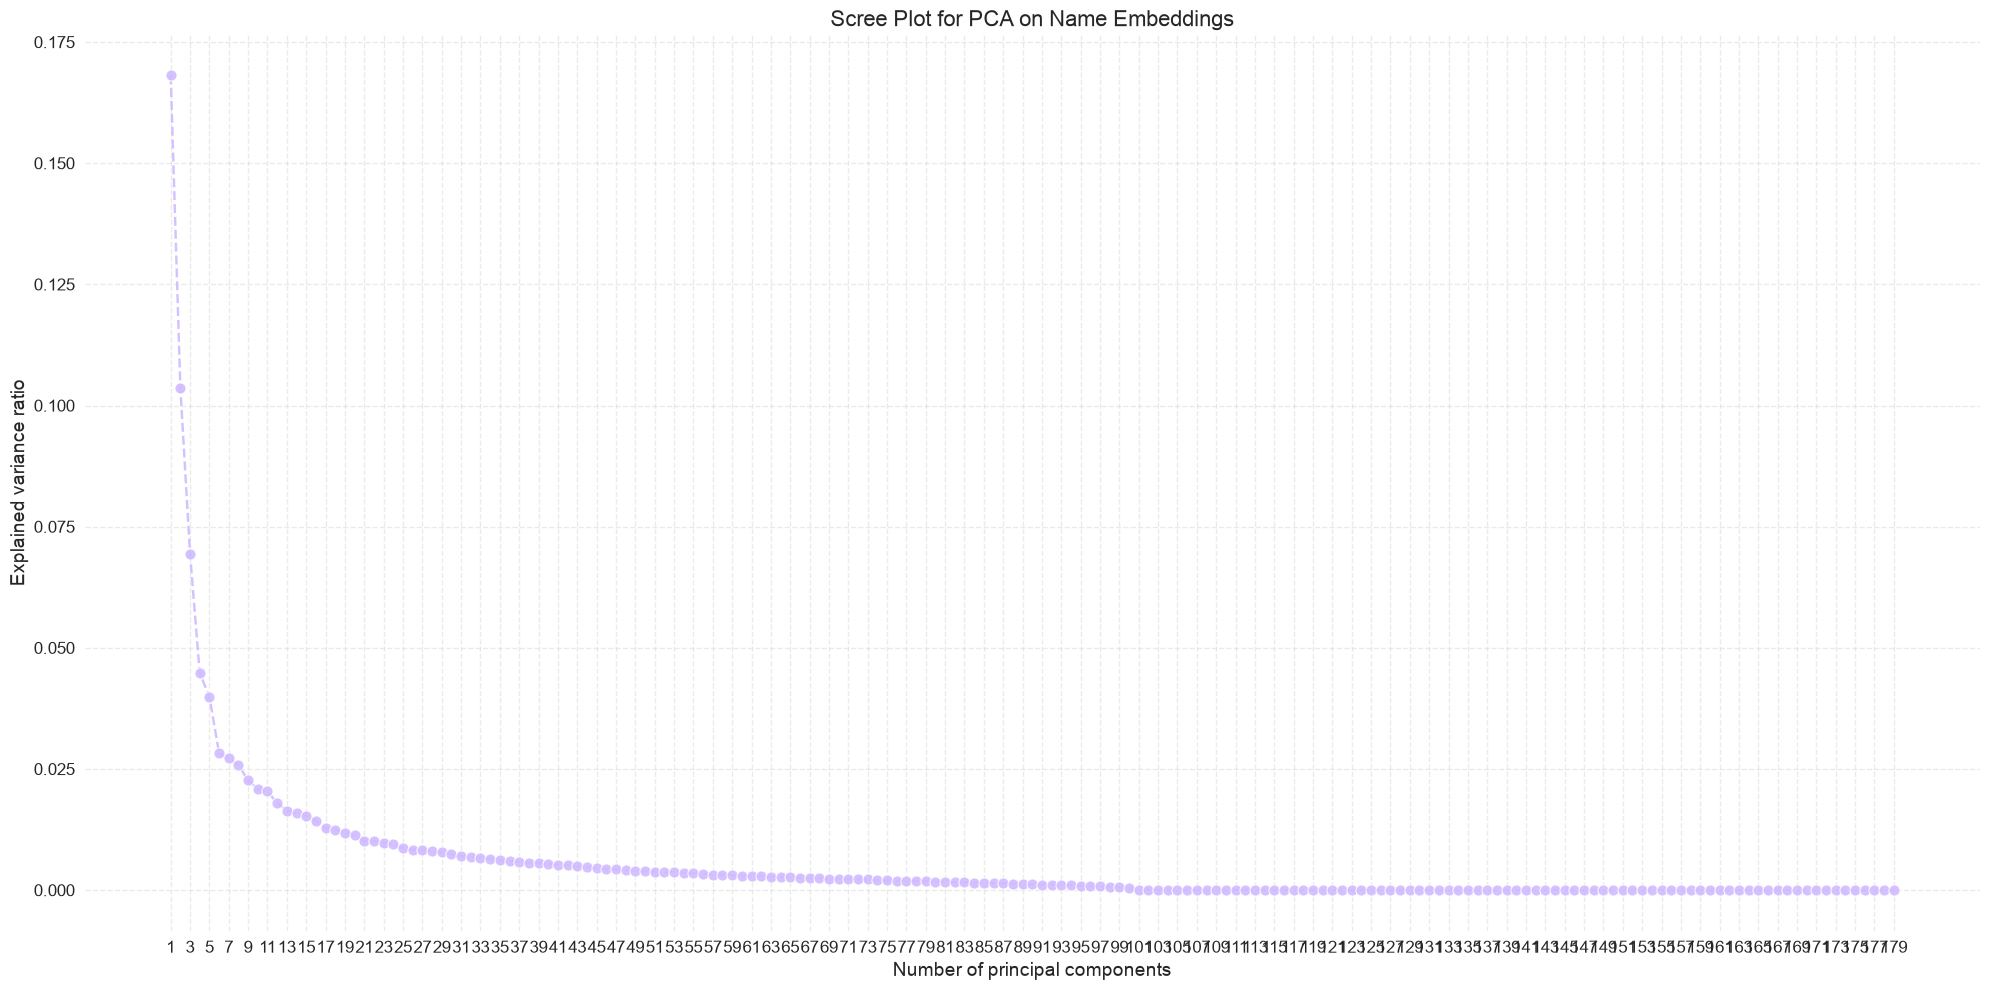

In [33]:
#Creating a Scree Plot to determine the optimal number of Components
# Setting style
sns.set_style('whitegrid', {'axes.edgecolor': '0', 
                            'xtick.bottom': True, 
                            'ytick.left': True, 
                            'grid.color': '.8', 
                            'axes.facecolor': 'white'})
# Creating the scree plot
fig, ax = plt.subplots(figsize = (20, 10))
sns.lineplot(x=range(1, len(explained_var_ratios) + 1), y = explained_var_ratios, 
             marker = 'o', markersize = 8, 
             linestyle = '--', color = sns.color_palette('pastel')[4], 
             alpha = 0.9, ax = ax)
#setting the labels and decreasing grid opacity
ax.set_xlabel('Number of principal components', fontsize = 14)
ax.set_ylabel('Explained variance ratio', fontsize=14)
ax.set_title('Scree Plot for PCA on Name Embeddings', fontsize = 16, fontweight = 400)
ax.grid(linestyle = '--', alpha = 0.4)
# Setting x-axis ticks to show every 2nd instance
plt.xticks(range(1, len(explained_var_ratios) + 1, 2), fontsize=12)
plt.yticks(fontsize=12)
#adjusting layout
plt.tight_layout()
plt.show();

After consideration, 8 components were deemed optimal for the given data. Hence, initialising the PCA instance with the number of components desired.

In [34]:
# Choosing 8 components based on the elbow method performed above
PCA_name = PCA(n_components = 8) 
#the PCA object with 8 components was fitted into training data a
#a nd both training and test data transformed into a novel space,
#representing reduced dimensionality matrix.
# Fitting the PCA model to the PCA_train 
PCA_name.fit(PCA_train)
# Transforming the data to the new space
#and storing the data in variables
PCA_train_trans = PCA_name.transform(PCA_train)
PCA_test_trans = PCA_name.transform(PCA_test)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",8
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [35]:
#array representing transformed training PCA data
#where each column represents a PC
#each row repredents a data point 
PCA_train_trans

array([[ 0.30145773,  0.37842287, -0.02397984, ...,  0.39429197,
        -0.74105792, -0.13319918],
       [-0.13016507,  0.64198786,  0.02734384, ...,  0.08920503,
        -0.12119882, -0.10366266],
       [ 1.90094   ,  0.78848932, -0.15945772, ..., -0.52890707,
        -0.14980063,  0.72923225],
       ...,
       [ 1.47731811,  1.15712562, -0.12790917, ...,  0.20564172,
        -0.28815082,  0.06041886],
       [-0.1752734 , -0.67574977, -0.88313488, ...,  0.71907183,
        -0.03823691,  0.24959106],
       [-0.0086136 ,  0.10606462,  0.03593465, ..., -0.05544211,
        -0.25204987,  0.56035214]], shape=(39107, 8))

In [36]:
#array representing transformed testing PCA data
PCA_test_trans

array([[-0.25164669, -0.36770878, -0.13250388, ..., -0.26817102,
         0.19625661, -0.12059007],
       [-1.27607221,  0.39757038,  1.08482862, ..., -0.10122025,
         0.0023939 , -0.07960325],
       [ 0.51781593,  0.33095004, -0.30720107, ..., -0.09623973,
         0.2275274 , -0.2055204 ],
       ...,
       [-1.18897957, -0.7727506 ,  0.08059392, ...,  0.52975247,
         0.06784564,  0.09693587],
       [ 0.41752502, -0.12293567,  0.43219459, ..., -0.13464271,
        -0.48379962,  0.37935913],
       [ 0.94252419, -0.486772  ,  0.71574069, ..., -0.24770151,
         0.12998325, -0.09737569]], shape=(9777, 8))

In [37]:
# extracting the loadings for the Principal Components identified through the PCA process
#They indicate the relationship's strength and direction between toriginal variables and every PC
PCA_name_loadings = PCA_name.components_
#checking the loadings
PCA_name_loadings

array([[ 0.0428958 , -0.00081642, -0.0513152 , ...,  0.00036165,
        -0.001548  ,  0.00098362],
       [ 0.10560339,  0.03372583,  0.00182673, ..., -0.00143308,
         0.00210169, -0.00289324],
       [ 0.16963796, -0.16008057,  0.04602757, ..., -0.00134776,
        -0.0002852 , -0.00221801],
       ...,
       [ 0.03392063, -0.02408162,  0.02677142, ...,  0.00132204,
         0.00107609, -0.00475947],
       [ 0.04549309,  0.01510851,  0.01773136, ...,  0.00447851,
        -0.00401026, -0.0022099 ],
       [ 0.03740254,  0.05038687, -0.04574747, ...,  0.00174047,
        -0.00024879, -0.00158568]], shape=(8, 179))

In [38]:
# Examining the explained variance of all variables to determine original data's proportion captured by the reduced PC set.
# obtaining a list of values where each value corresponds to
# % variance explained by the matching PC
var_exp = PCA_name.explained_variance_ratio_
print('Explained variance:', var_exp)

Explained variance: [0.16814873 0.1036043  0.06939067 0.04482425 0.03990995 0.0282493
 0.02719997 0.02578153]


In [39]:
# Identifying the most important variables
name_comp_loadings = pd.DataFrame(PCA_name.components_.T, 
                        columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'],
                        index = df_PCA.columns)
print(f'Loadings: {name_comp_loadings}')

Loadings:                          PC1       PC2       PC3       PC4       PC5  \
name_embedding_1    0.042896  0.105603  0.169638  0.126584  0.274138   
name_embedding_2   -0.000816  0.033726 -0.160081 -0.021665 -0.024447   
name_embedding_3   -0.051315  0.001827  0.046028 -0.172085 -0.008969   
name_embedding_4    0.018970  0.084526  0.080194 -0.045208 -0.181132   
name_embedding_5   -0.044276  0.002011  0.109234 -0.030488  0.179817   
...                      ...       ...       ...       ...       ...   
name_embedding_175 -0.001377  0.006266 -0.004094 -0.000340  0.004412   
name_embedding_176 -0.000195  0.002199 -0.000281 -0.001284  0.003554   
name_embedding_177  0.000362 -0.001433 -0.001348  0.001992 -0.004632   
name_embedding_178 -0.001548  0.002102 -0.000285 -0.002278 -0.006976   
name_embedding_179  0.000984 -0.002893 -0.002218 -0.002592 -0.001011   

                         PC6       PC7       PC8  
name_embedding_1    0.033921  0.045493  0.037403  
name_embedding_2   -0.0

In [40]:
#Most important components
# extracting the  loadings of the principal components
loadings = PCA_name.components_
# creating a dictionary to store the most important variables and explained variance
component_info = {}
# looping over the components
for i in range(len(loadings)):
    # obtaining absolute loadings' values for this component
    abs_loadings = np.abs(loadings[i])
    # obtaining variables' indices sorted by their importance
    sorted_indices = np.argsort(abs_loadings)[::-1]
    # obtaining variables' names sorted by their importance
    sorted_vars = PCA_train.columns[sorted_indices]
    # storing names of top 3 most important variables for this component
    most_important_vars = list(sorted_vars[:3])
    # storing absolute loadings for most important variables
    most_important_loadings = [abs_loadings[j] for j in sorted_indices[:3]]
    # storing the explained variance for this component
    explained_variance = PCA_name.explained_variance_ratio_[i]
    # storing the component info in a dictionary
    component_info[f'Component {i+1}'] = {'most_important_vars': most_important_vars,
                                         'most_important_loadings': most_important_loadings,
                                         'explained_variance': explained_variance}
# creating a df to display the explained variance for each component
explained_variance_df = pd.DataFrame({'Component': [f'Component {i+1}' for i in range(len(loadings))],
                                      'Explained Variance': PCA_name.explained_variance_ratio_})
# displaying the most important variables and loadings for each component in a table
print('Most important variables for each component:')
for key, value in component_info.items():
    print(f'{key}:')
    print(pd.DataFrame({'Variable': value['most_important_vars'],
                         'Loading': value['most_important_loadings']}))
    print(f'Explained variance: {value["explained_variance"]:.2f}')
    print()
# displaying the explained variance for each component
print(f'Explained variance for each component: {explained_variance_df}')

Most important variables for each component:
Component 1:
            Variable   Loading
0  name_embedding_56  0.550028
1  name_embedding_59  0.391153
2  name_embedding_85  0.266764
Explained variance: 0.17

Component 2:
            Variable   Loading
0  name_embedding_67  0.240210
1  name_embedding_56  0.228010
2   name_embedding_6  0.224528
Explained variance: 0.10

Component 3:
            Variable   Loading
0  name_embedding_50  0.267585
1  name_embedding_76  0.217605
2  name_embedding_85  0.205915
Explained variance: 0.07

Component 4:
            Variable   Loading
0  name_embedding_97  0.325980
1  name_embedding_47  0.230338
2  name_embedding_62  0.220004
Explained variance: 0.04

Component 5:
            Variable   Loading
0   name_embedding_1  0.274138
1  name_embedding_89  0.245260
2  name_embedding_73  0.235431
Explained variance: 0.04

Component 6:
            Variable   Loading
0  name_embedding_88  0.267511
1  name_embedding_98  0.250691
2  name_embedding_72  0.226004
Exp

In [41]:
# Adding new columns to the PCA_train and PCA_test datasets for each component
for i in range(PCA_name.n_components_):
    col_name = f'component_{i+1}'
    PCA_train[col_name] = PCA_train_trans[:, i]
    PCA_test[col_name] = PCA_test_trans[:, i]

Mapping word indices back to corresponding words and checking top 8 words for each PC to

In [42]:
#checking which words each component corresponds to 
#Creating the idx2word dictionnary to allow for further lookup at 
#original words based on their numerical indices in tokeniser's vocabulary. 
idx2word = {v:k for k,v in tokenizer.word_index.items()}
for i, comp in enumerate(PCA_name.components_):
    #checking the 8 words that correspond to each PC
    indices = np.argsort(comp)[::-1][:8]
    #utilising the idx2word dictionnary created earlier to map word indices
    #back to words
    variables = [idx2word[idx] for idx in indices if idx in idx2word]
    #printing the words and explained variance for each PC
    print(f'Component {i+1}:')
    for j, variable in enumerate(variables):
        print(f"{j+1}. {variable}")
    print(f'Explained variance: {PCA_name.explained_variance_ratio_[i]:.2f}')

Component 1:
1. bath
2. entire
3. best
4. soho
5. charming
6. great
7. slope
8. subway
Explained variance: 0.17
Component 2:
1. house
2. apartment
3. new
4. perfect
5. brownstone
6. location
7. apt
8. comfy
Explained variance: 0.10
Component 3:
1. great
2. entire
3. floor
4. quiet
5. views
6. york
7. studio
Explained variance: 0.07
Component 4:
1. jfk
2. the
3. lovely
4. garden
5. by
6. townhouse
7. spacious
8. side
Explained variance: 0.04
Component 5:
1. times
2. studio
3. private
4. astoria
5. big
6. nyc
7. bushwick
Explained variance: 0.04
Component 6:
1. bd
2. bdrm
3. jfk
4. bath
5. quiet
6. manhattan
7. greenpoint
8. bed
Explained variance: 0.03
Component 7:
1. subway
2. the
3. heart
4. bright
5. loft
6. best
7. of
8. bd
Explained variance: 0.03
Component 8:
1. east
2. place
3. quiet
4. garden
5. hill
6. for
7. brooklyn
8. location
Explained variance: 0.03


In [43]:
# merging PCA_train and PCA_test
#Once the data has been transformed for both sets
df_PCA_merged = pd.concat([PCA_train, PCA_test], axis = 0)

In [44]:
#checking that the merge was successful
df_PCA_merged.iloc[:, :10].head()
df_PCA_merged.iloc[:, -9:].head()

,name_embedding_1,name_embedding_2,name_embedding_3,name_embedding_4,name_embedding_5,name_embedding_6,name_embedding_7,name_embedding_8,name_embedding_9,name_embedding_10
1295,0.157139,0.182858,0.320134,0.120451,-0.040404,0.452806,-0.082988,0.336084,-0.094270,0.371868
22583,-0.002928,0.234353,0.194641,0.156609,0.205832,0.575552,0.035676,0.583577,-0.247043,0.323173
9988,0.152911,0.218491,0.285875,0.302280,-0.221417,0.174205,0.132472,0.396505,-0.019825,0.718275
29155,0.230352,0.110016,0.172913,-0.162197,-0.094863,0.271356,-0.027155,0.201098,-0.287483,0.253664
25905,-0.051397,0.100668,0.188258,-0.098664,0.369312,0.057662,-0.075146,0.585990,-0.347643,0.121276


,name_embedding_179,component_1,component_2,component_3,component_4,component_5,component_6,component_7,component_8
1295,-0.008104,0.301458,0.378423,-0.023980,0.023237,0.173534,0.394292,-0.741058,-0.133199
22583,-0.020476,-0.130165,0.641988,0.027344,-0.735580,0.151300,0.089205,-0.121199,-0.103663
9988,-0.020813,1.900940,0.788489,-0.159458,0.403461,-0.117667,-0.528907,-0.149801,0.729232
29155,0.016790,0.997020,-0.537752,0.345285,0.209157,0.058081,0.319454,-0.369896,-0.373280
25905,-0.016573,0.426777,-0.253469,-0.264248,-1.029985,0.253001,-0.302063,0.249286,-0.073285


In [45]:
# creating new merged dataframe, storing original variables and obtained PCs 
#which will be utilised in the subsequent 
# concatenating the 2 dfs column-wise
#df_merged = pd.concat([df, df_PCA_merged], axis=1)
df_merged = pd.concat([df.reset_index(drop = True),
                      df_PCA_merged.reset_index(drop = True)], axis = 1)
df_merged = df_merged.loc[:, ~df_merged.columns.str.startswith('Unnamed')]

In [46]:
#checking the head of the merged df
df_merged.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,...,name_embedding_178,name_embedding_179,component_1,component_2,component_3,component_4,component_5,component_6,component_7,component_8
0,Brooklyn,40.72488,-73.950180,Private room,55.0,2.0,1.0,1463270.0,0.01,1.0,...,0.005546,-0.008104,0.301458,0.378423,-0.023980,0.023237,0.173534,0.394292,-0.741058,-0.133199
1,Brooklyn,40.70207,-73.985710,Private room,250.0,3.0,14.0,1463270.0,0.13,1.0,...,0.006126,-0.020476,-0.130165,0.641988,0.027344,-0.735580,0.151300,0.089205,-0.121199,-0.103663
2,Brooklyn,40.73842,-73.953120,Private room,249.0,3.0,2.0,1463270.0,0.02,15.0,...,-0.014598,-0.020813,1.900940,0.788489,-0.159458,0.403461,-0.117667,-0.528907,-0.149801,0.729232
3,Brooklyn,40.71923,-73.964680,Private room,90.0,1.0,9.0,1463270.0,0.08,1.0,...,0.020514,0.016790,0.997020,-0.537752,0.345285,0.209157,0.058081,0.319454,-0.369896,-0.373280
4,Queens,40.74028,-73.865771,Private room,140.0,2.0,1.0,1463270.0,0.01,1.0,...,0.003317,-0.016573,0.426777,-0.253469,-0.264248,-1.029985,0.253001,-0.302063,0.249286,-0.073285


After name_embedding columns' lower-dimensional representation capturing maximum variation wascreated and PCs concatenated with original data, name_embedding columns are now redundant.

In [47]:
#dropping the name_embedding columns
#creating a function to drop the name_embedding columns
def drop_name_embedding_columns(df):
    cols_to_drop = [col for col in df.columns if col.startswith('name_embedding')]
    df.drop(cols_to_drop, axis=1, inplace=True)
#applying th efunction to the merged_df to drop the name embedding columns
drop_name_embedding_columns(df_merged)

In [48]:
print(f'Now the merged dataframe has {len(df_merged.columns)} columns!')

Now the merged dataframe has 19 columns!


In [49]:
#renaming the columns for the Principal Components 
#after analysing the top words for each PC
#giving them descreaption corresponding associated words' aggregated meaning
#so that they correspond to their respective 'name' descriptions
df_merged.rename(columns = {'component_1': 'Luxury_Place',
                           'component_2': 'Perfect_Location',
                           'component_3': 'New_apt_with_view', 
                           'component_4': 'Piece_and_Quiet',
                           'component_5': 'Big_private_Studio_by_Astoria',
                           'component_6': 'Prime_Stuite_with_large_bed_and_floor',
                           'component_7': 'Subway_Closeness',
                           'component_8': 'Quiet_East_Place_with_Garden'}, inplace=True)
#checking that the renaming of components worked correctly
df_merged.columns

Index(['neighbourhood_group', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'Luxury_Place', 'Perfect_Location',
       'New_apt_with_view', 'Piece_and_Quiet', 'Big_private_Studio_by_Astoria',
       'Prime_Stuite_with_large_bed_and_floor', 'Subway_Closeness',
       'Quiet_East_Place_with_Garden'],
      dtype='str')

In [50]:
#renaming other columns to facilitate understanding 
df_merged.rename(columns = {'calculated_host_listings_count': 'total_host_listings',
                           'availability_365': 'Days_per_year_available',
                           'price': 'price_dollars'}, inplace = True)
#checking that the renaming of components worked correctly
print(df_merged.columns)

Index(['neighbourhood_group', 'latitude', 'longitude', 'room_type',
       'price_dollars', 'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'total_host_listings', 'Days_per_year_available',
       'Luxury_Place', 'Perfect_Location', 'New_apt_with_view',
       'Piece_and_Quiet', 'Big_private_Studio_by_Astoria',
       'Prime_Stuite_with_large_bed_and_floor', 'Subway_Closeness',
       'Quiet_East_Place_with_Garden'],
      dtype='str')


### 2.3.3. One-Hot-Encoding (OHE) for categorical variables

Finally, performing OHE to make categorical variables suitable for ML models.

In [51]:
#One-Hot-Encoding for neighbourhood_group
#creating dummy variables for each 'neighboud_group' unique value
##and storing them in a variable
dummies_neighbourhood_group = pd.get_dummies(df_merged.neighbourhood_group)
dummies_neighbourhood_group.head()
# Concatenating dummies_neighbourhood_group to the merged df
#and dopping the original categorical 'neighbourhood_group' column
#since it is no longer needed
df_merged = pd.concat([df_merged, dummies_neighbourhood_group],
                     axis= 1).drop(['neighbourhood_group'], axis = 1)
df_merged.head()

,Bronx,Brooklyn,Manhattan,Queens,Staten Island
0,False,True,False,False,False
1,False,True,False,False,False
2,False,True,False,False,False
3,False,True,False,False,False
4,False,False,False,True,False


,latitude,longitude,room_type,price_dollars,minimum_nights,number_of_reviews,last_review,reviews_per_month,total_host_listings,Days_per_year_available,...,Piece_and_Quiet,Big_private_Studio_by_Astoria,Prime_Stuite_with_large_bed_and_floor,Subway_Closeness,Quiet_East_Place_with_Garden,Bronx,Brooklyn,Manhattan,Queens,Staten Island
0,40.72488,-73.950180,Private room,55.0,2.0,1.0,1463270.0,0.01,1.0,0.0,...,0.023237,0.173534,0.394292,-0.741058,-0.133199,False,True,False,False,False
1,40.70207,-73.985710,Private room,250.0,3.0,14.0,1463270.0,0.13,1.0,189.0,...,-0.735580,0.151300,0.089205,-0.121199,-0.103663,False,True,False,False,False
2,40.73842,-73.953120,Private room,249.0,3.0,2.0,1463270.0,0.02,15.0,60.0,...,0.403461,-0.117667,-0.528907,-0.149801,0.729232,False,True,False,False,False
3,40.71923,-73.964680,Private room,90.0,1.0,9.0,1463270.0,0.08,1.0,245.0,...,0.209157,0.058081,0.319454,-0.369896,-0.373280,False,True,False,False,False
4,40.74028,-73.865771,Private room,140.0,2.0,1.0,1463270.0,0.01,1.0,1.0,...,-1.029985,0.253001,-0.302063,0.249286,-0.073285,False,False,False,True,False


In [52]:
# Performing One-Hot-Encoding to conduct Predictive Models (all IVs treated equally
# Creating dummy variables for each unique category in 'room_type'
#and storing them in a variable
dummy_room = pd.get_dummies(df_merged.room_type)
dummy_room.head()
# Concatenating dummies (dummy_room) to the merged df
#and dopping the original categorical 'room_type' column
#since it is no longer needed
df_merged = pd.concat([df_merged, dummy_room],
               axis = 1).drop(['room_type'], axis = 1)
df_merged.head()

,Entire home/apt,Private room,Shared room
0,False,True,False
1,False,True,False
2,False,True,False
3,False,True,False
4,False,True,False


,latitude,longitude,price_dollars,minimum_nights,number_of_reviews,last_review,reviews_per_month,total_host_listings,Days_per_year_available,Luxury_Place,...,Subway_Closeness,Quiet_East_Place_with_Garden,Bronx,Brooklyn,Manhattan,Queens,Staten Island,Entire home/apt,Private room,Shared room
0,40.72488,-73.950180,55.0,2.0,1.0,1463270.0,0.01,1.0,0.0,0.301458,...,-0.741058,-0.133199,False,True,False,False,False,False,True,False
1,40.70207,-73.985710,250.0,3.0,14.0,1463270.0,0.13,1.0,189.0,-0.130165,...,-0.121199,-0.103663,False,True,False,False,False,False,True,False
2,40.73842,-73.953120,249.0,3.0,2.0,1463270.0,0.02,15.0,60.0,1.900940,...,-0.149801,0.729232,False,True,False,False,False,False,True,False
3,40.71923,-73.964680,90.0,1.0,9.0,1463270.0,0.08,1.0,245.0,0.997020,...,-0.369896,-0.373280,False,True,False,False,False,False,True,False
4,40.74028,-73.865771,140.0,2.0,1.0,1463270.0,0.01,1.0,1.0,0.426777,...,0.249286,-0.073285,False,False,False,True,False,False,True,False


In [53]:
###

In [54]:
#checking that all NaN values have been renmoved after transformations.
df_merged.isna().sum()

latitude                                 0
longitude                                0
price_dollars                            0
minimum_nights                           0
number_of_reviews                        0
last_review                              0
reviews_per_month                        0
total_host_listings                      0
Days_per_year_available                  0
Luxury_Place                             0
Perfect_Location                         0
New_apt_with_view                        0
Piece_and_Quiet                          0
Big_private_Studio_by_Astoria            0
Prime_Stuite_with_large_bed_and_floor    0
Subway_Closeness                         0
Quiet_East_Place_with_Garden             0
Bronx                                    0
Brooklyn                                 0
Manhattan                                0
Queens                                   0
Staten Island                            0
Entire home/apt                          0
Private roo

In [56]:
#Saving the cleaned data to a csv file so that all data cleaning steps
#do not have to be repeated upon creating predictive models
df_merged.to_csv('Airbnb_ml_project/data/processed/airbnb_part_2.csv')